Running simulations...
  Processing t=5, p=0.1...
  Processing t=5, p=0.25...
  Processing t=5, p=0.5...
  Processing t=20, p=0.1...
  Processing t=20, p=0.25...
  Processing t=20, p=0.5...
  Processing t=50, p=0.1...
  Processing t=50, p=0.25...
  Processing t=50, p=0.5...
  Processing t=80, p=0.1...
  Processing t=80, p=0.25...
  Processing t=80, p=0.5...

Plots saved!


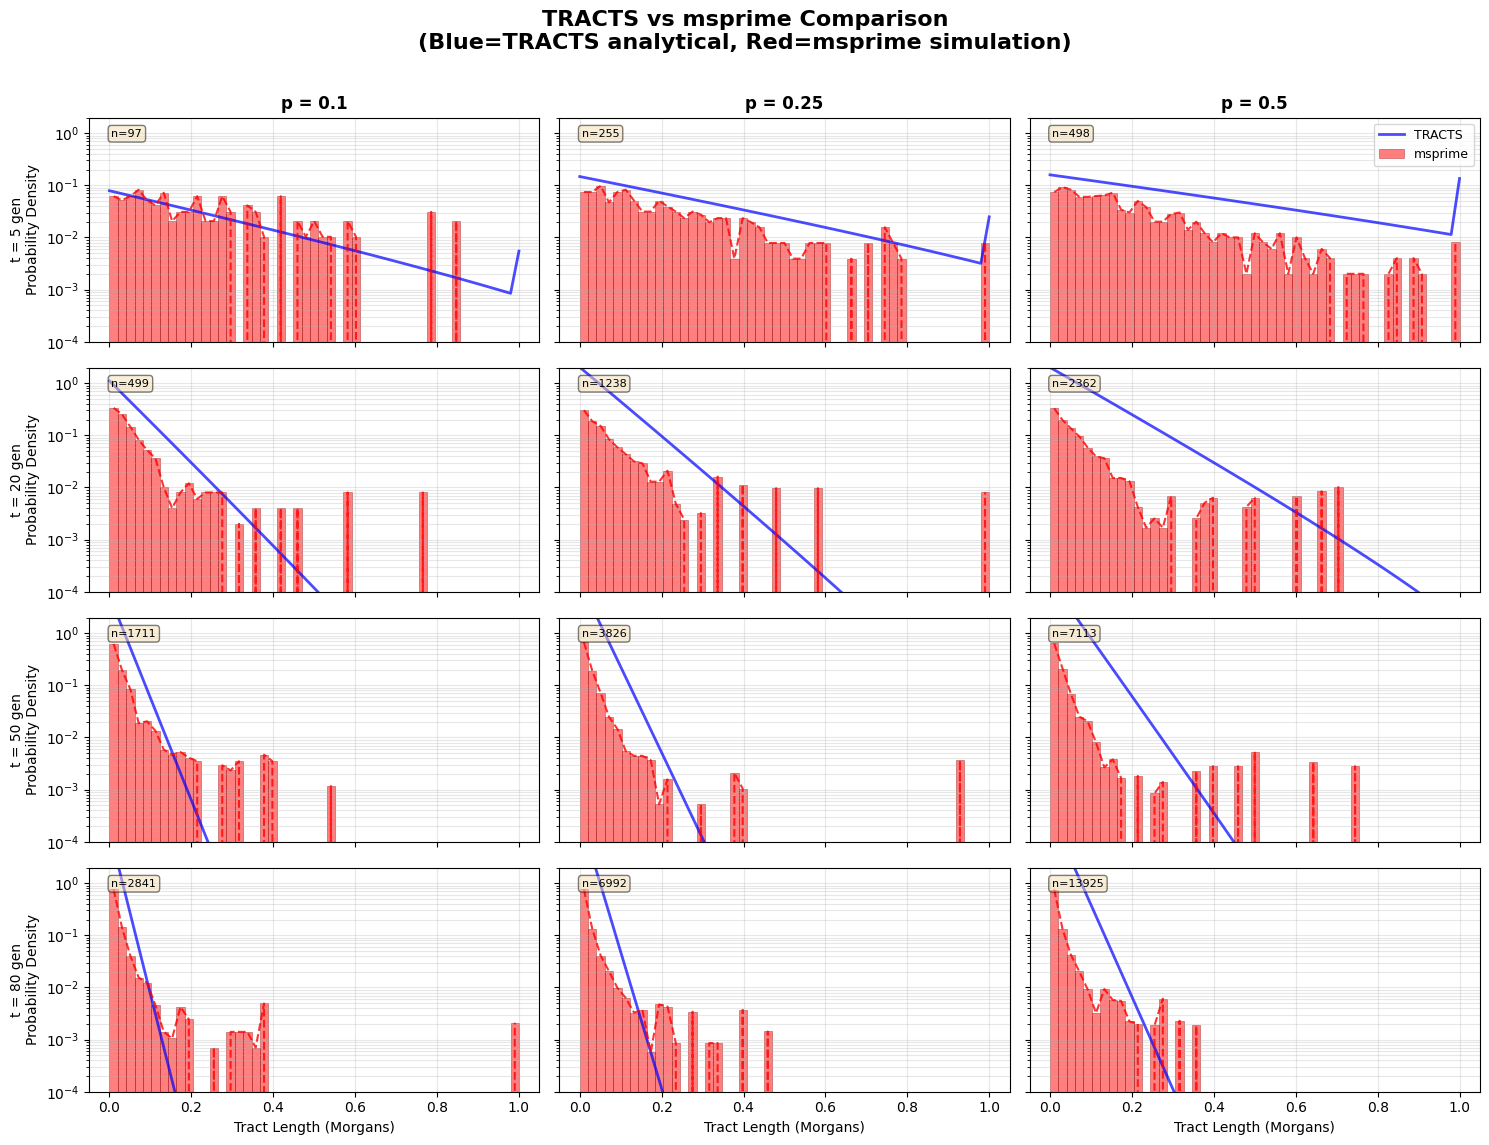

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

# Try to import tracts - we'll handle if it's not available
try:
    import tracts
    HAS_TRACTS = True
except ImportError:
    HAS_TRACTS = False
    print("Warning: tracts not available, will only show msprime results")

# ============================================================================
# SHARED PARAMETERS
# ============================================================================
times = [5, 20, 50, 80]  # Admixture times in generations
props = [0.10, 0.25, 0.50]  # Pop0 ancestry proportions
sequence_length = 1e8  # 100 Mb = 1 Morgan
r = 1e-8  # Recombination rate
Ne = 10000  # Effective population size
sample_size = 100  # Number of diploid samples
bins = np.linspace(0, 1.0, 50)  # 50 bins from 0 to 1 Morgan
Ls = [1.0]  # 1 Morgan for TRACTS

# ============================================================================
# FUNCTION: RUN MSPRIME SIMULATION
# ============================================================================
def run_msprime_simulation(t, p, rseed=42):
    """Run msprime simulation and extract tract lengths in Morgans"""
    
    # Create demography
    demography = msprime.Demography()
    demography.add_population(name="Pop0", initial_size=Ne)
    demography.add_population(name="Pop1", initial_size=Ne)
    demography.add_population(name="Pop2", initial_size=Ne)
    
    # Add mass migration events (backwards in time)
    demography.add_mass_migration(time=t, source="Pop1", dest="Pop0", proportion=p)
    demography.add_mass_migration(time=t, source="Pop1", dest="Pop2", proportion=1.0)
    
    # Run simulation
    ts = msprime.sim_ancestry(
        samples={"Pop1": sample_size},
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t+1,
        record_migrations=True,
        random_seed=rseed
    )
    
    # Extract tracts
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size
    
    # Build children cache
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    # Extract tracts for each population
    tracts = [[], [], []]
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts[row.dest].append(seg_length)
    
    # Convert to Morgans
    tracts_morgans = [np.array(t) / sequence_length for t in tracts]
    
    return tracts_morgans[0]  # Return Pop0 tracts

# ============================================================================
# FUNCTION: RUN TRACTS MODEL
# ============================================================================
def run_tracts_model(t, p):
    """Run TRACTS demographic model"""
    if not HAS_TRACTS:
        return None
    
    # Build migration matrix (rows=generations, cols=populations)
    mig = np.zeros((t + 1, 2))
    mig[t, 0] = p
    mig[t, 1] = 1.0 - p
    
    # Create demographic model
    model = tracts.DemographicModel(mig)
    y = model.expectperbin(Ls, 0, bins)
    
    return y

# ============================================================================
# RUN ALL SIMULATIONS AND CREATE COMPARISON PLOT
# ============================================================================
print("Running simulations...")

fig, axes = plt.subplots(len(times), len(props), figsize=(15, 12), sharex=True, sharey=True)

for i, t in enumerate(times):
    for j, p in enumerate(props):
        print(f"  Processing t={t}, p={p}...")
        
        ax = axes[i, j]
        
        # Run TRACTS model
        if HAS_TRACTS:
            tracts_y = run_tracts_model(t, p)
            ax.plot(bins, tracts_y, 'b-', linewidth=2, label='TRACTS', alpha=0.7)
        
        # Run msprime simulation
        msprime_tracts = run_msprime_simulation(t, p, rseed=42+i*10+j)
        
        # Create histogram for msprime results
        counts, bin_edges = np.histogram(msprime_tracts, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # Plot msprime as filled histogram
        ax.bar(bin_centers, counts * bin_width, width=bin_width, 
               alpha=0.5, color='red', edgecolor='darkred', 
               linewidth=0.5, label='msprime')
        
        # Also plot as line for easier comparison
        ax.plot(bin_centers, counts * bin_width, 'r--', 
                linewidth=1.5, alpha=0.8)
        
        # Formatting
        ax.set_yscale('log')
        ax.set_ylim([1e-4, 2])
        ax.grid(True, alpha=0.3, which='both')
        
        # Labels
        if i == 0:
            ax.set_title(f"p = {p}", fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f"t = {t} gen\nProbability Density", fontsize=10)
        if i == len(times)-1:
            ax.set_xlabel("Tract Length (Morgans)", fontsize=10)
        if i == 0 and j == len(props)-1:
            ax.legend(fontsize=9, loc='upper right')
        
        # Add text with number of msprime tracts
        ax.text(0.05, 0.95, f'n={len(msprime_tracts)}', 
                transform=ax.transAxes, fontsize=8,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("TRACTS vs msprime Comparison\n(Blue=TRACTS analytical, Red=msprime simulation)", 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

# Save the plot
plt.savefig("TRACTS_vs_msprime_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("TRACTS_vs_msprime_comparison.pdf", bbox_inches='tight')
print("\nPlots saved!")

plt.show()